## compare between trained models (according to sleap docs)

In [1]:
# only need to run on first creation on conda env 
!pip uninstall -qqq -y opencv-python opencv-contrib-python
!pip install -qqq "sleap[pypi]>=1.3.3"
!pip install tree


ERROR: Cannot uninstall opencv-python 4.5.5, RECORD file not found. Hint: The package was installed by conda.


In [2]:
import os
import sleap
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.style.use("seaborn-deep")
sleap.versions()

c:\Users\esay\.conda\envs\sleap_v2\lib\site-packages\shiboken2\files.dir\shibokensupport\signature\parser.py:191: RuntimeWarning: pyside_type_init:

        UNRECOGNIZED:   'PySide2.QtCore.QString'
        OFFENDING LINE: 'PySide2.QtWidgets.QFileDialog.getOpenFileName(parent:PySide2.QtWidgets.QWidget=nullptr,caption:QString=QString(),dir:QString=QString(),filter:QString=QString(),selectedFilter:PySide2.QtCore.QString=QString(),options:PySide2.QtWidgets.QFileDialog.Options=QFileDialog.Options())->QString'
        
  """.format(thing, line), RuntimeWarning)
c:\Users\esay\.conda\envs\sleap_v2\lib\site-packages\shiboken2\files.dir\shibokensupport\signature\parser.py:191: RuntimeWarning: pyside_type_init:

        UNRECOGNIZED:   'PySide2.QtCore.QString'
        OFFENDING LINE: 'PySide2.QtWidgets.QFileDialog.getOpenFileNames(parent:PySide2.QtWidgets.QWidget=nullptr,caption:QString=QString(),dir:QString=QString(),filter:QString=QString(),selectedFilter:PySide2.QtCore.QString=QString(),option

SLEAP: 1.3.4
TensorFlow: 2.7.0
Numpy: 1.21.6
Python: 3.7.12
OS: Windows-10-10.0.26100-SP0


In [57]:
data_dir = "C://Users/esay/data/social_interaction/models"
# model = "241210_143147.single_instance.n=1794"
# latest_model = "250113_165658.single_instance.n=2844"
# model_dir = os.path.join(data_dir, model)
# latest_dir = os.path.join(data_dir, latest_model)

all_models = [os.path.join(data_dir,p) for p in os.listdir(data_dir)]

all_models

['C://Users/esay/data/social_interaction/models\\241217_133127.single_instance.n=2451',
 'C://Users/esay/data/social_interaction/models\\250127_164147.single_instance.n=2844',
 'C://Users/esay/data/social_interaction/models\\250915_092122.centroid.n=2598',
 'C://Users/esay/data/social_interaction/models\\250915_095749.centered_instance.n=2598']

In [4]:
!tree {model_dir}

Folder PATH listing
Volume serial number is BEA9-8BE7
C:\USERS\ESAY\REPOS\SOCIAL_INT_ANALYSES\SOCIAL_INT_NOTEBOOKS\SLEAP\{MODEL_DIR}
Invalid path - \USERS\ESAY\REPOS\SOCIAL_INT_ANALYSES\SOCIAL_INT_NOTEBOOKS\SLEAP\{MODEL_DIR}
No subfolders exist 



In [10]:
help(sleap.load_metrics)

Help on function load_metrics in module sleap.nn.evals:

load_metrics(model_path: str, split: str = 'val') -> typing.Dict[str, typing.Any]
    Load metrics for a model.
    
    Args:
        model_path: Path to a model folder or metrics file (.npz).
        split: Name of the split to load the metrics for. Must be `"train"`, `"val"` or
            `"test"` (default: `"val"`). Ignored if a path to a metrics NPZ file is
            provided.
    
    Returns:
        The loaded metrics as a dictionary with keys:
    
        - `"vis.tp"`: Visibility - True Positives
        - `"vis.fp"`: Visibility - False Positives
        - `"vis.tn"`: Visibility - True Negatives
        - `"vis.fn"`: Visibility - False Negatives
        - `"vis.precision"`: Visibility - Precision
        - `"vis.recall"`: Visibility - Recall
        - `"dist.avg"`: Average Distance (ground truth vs prediction)
        - `"dist.p50"`: Distance for 50th percentile
        - `"dist.p75"`: Distance for 75th percentile
  

In [9]:
data_dir = "C:/Users/esay/data/social_interaction/models/"
model = "250915_095749.centered_instance.n=2598"
latest_model = "241216_161053.single_instance.n=2431"
model_dir = os.path.join(data_dir, model)
latest_dir = os.path.join(data_dir, latest_model)
metrics = sleap.load_metrics(model_dir, split="val")
latest_metrics = sleap.load_metrics(latest_dir, split="val")

# print("\n".join(metrics.keys()))

In [58]:
# metrics = sleap.load_metrics(model_dir, split="val")
# latest_metrics = sleap.load_metrics(latest_dir, split="val")

all_metrics = pd.DataFrame()
for model in all_models:
    metrics = sleap.load_metrics(model, split = "val")
    metrics['model_name'] = model
    all_metrics = all_metrics.append(metrics,ignore_index=True)

# print(all_metrics.head())
# print("\n".join(all_metrics.keys()))

In [59]:
all_metrics

,vis.tp,vis.fp,vis.tn,vis.fn,vis.precision,vis.recall,dist.frame_idxs,dist.video_paths,dist.dists,dist.avg,...,pck_voc.match_score_thresholds,pck_voc.recall_thresholds,pck_voc.match_scores,pck_voc.precisions,pck_voc.recalls,pck_voc.AP,pck_voc.AR,pck_voc.mAP,pck_voc.mAR,model_name
0,1346,2,0,122,0.9985163204747775,0.9168937329700273,"[16560, 5520, 13012, 16018, 16935, 15640, 1645...",[Z:/giocomo/esay/cd_project/behavior/videos/da...,"[[7.517915803182966, 16.735744113633327, 4.782...",6.967816,...,"[0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0...","[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[0.9500000000000001, 0.7166666666666667, 0.950...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[0.6816326530612244, 0.6040816326530613, 0.546...","[0.6496166628662466, 0.55994756738427, 0.49565...","[0.6816326530612244, 0.6040816326530613, 0.546...",0.291122,0.338367,C://Users/esay/data/social_interaction/models\...
1,1550,0,0,154,1.0,0.9096244131455399,"[1328, 13800, 10332, 920, 17252, 18215, 7013, ...",[Z:/giocomo/esay/cd_project/behavior/videos/da...,"[[15.988649404240205, 2.0915064057951813, 6.89...",8.200088,...,"[0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0...","[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[0.7833333333333332, 0.7166666666666667, 0.833...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.98...","[0.6690140845070423, 0.573943661971831, 0.5070...","[0.6273465857653989, 0.5124353716369124, 0.431...","[0.6690140845070423, 0.573943661971831, 0.5070...",0.236759,0.294014,C://Users/esay/data/social_interaction/models\...
2,1560,0,0,0,1.0,1.0,"[2760, 99, 11134, 12880, 16451, 9242, 15839, 1...",[C:/Users/esay/data/social_interaction/SLEAP_r...,"[[2.0797445472453546e-06, 1.611557465212532e-0...",0.000004,...,"[0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0...","[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.000000,1.000000,C://Users/esay/data/social_interaction/models\...
3,1521,1,0,38,0.9993429697766097,0.9756254008980115,"[13012, 16018, 7360, 11823, 9573, 10154, 18215...",[C:/Users/esay/data/social_interaction/SLEAP_r...,"[[9.087373258997165, 1.9489506673793777, 4.183...",8.098369,...,"[0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0...","[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[0.6833333333333332, 0.5666666666666665, 0.283...","[[1.0, 0.8461538461538461, 0.8461538461538461,...","[0.6384615384615384, 0.5230769230769231, 0.457...","[0.4439475396847107, 0.3219543623147764, 0.251...","[0.6384615384615384, 0.5230769230769231, 0.457...",0.134528,0.260000,C://Users/esay/data/social_interaction/models\...


In [11]:
print("Error distance (50%):", metrics["dist.p50"], latest_metrics["dist.p50"])
print("Error distance (90%):", metrics["dist.p90"], latest_metrics["dist.p90"])
print("Error distance (95%):", metrics["dist.p95"], latest_metrics["dist.p95"])

Error distance (50%): 3.810623474172406 2.62065048793609
Error distance (90%): 17.27028206373749 20.587725792557272
Error distance (95%): 27.634379557900687 44.16007828289442


### Plot localization errors (how far off the model is from ground truth location)

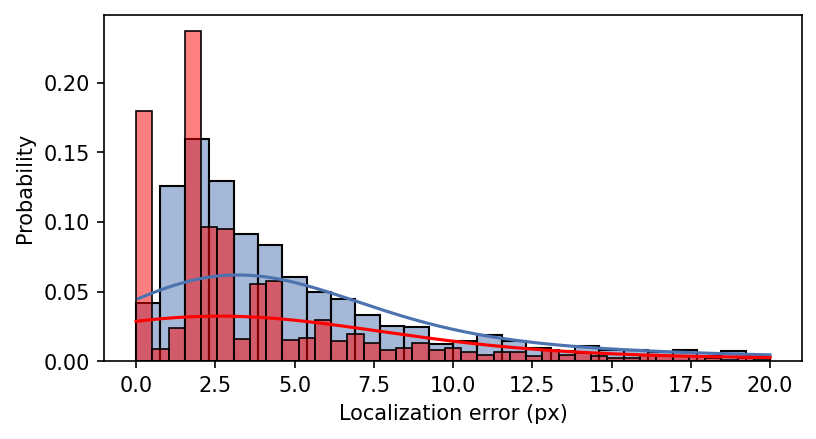

In [12]:

plt.figure(figsize=(6, 3), dpi=150, facecolor="w")

sns.histplot(metrics["dist.dists"].flatten(), binrange=(0, 20), kde=True, kde_kws={"clip": (0, 20)}, stat="probability")
sns.histplot(latest_metrics["dist.dists"].flatten(), binrange=(0, 20), kde=True, kde_kws={"clip": (0, 20)}, stat="probability", color="red")

plt.xlabel("Localization error (px)");

<AxesSubplot:ylabel='Density'>

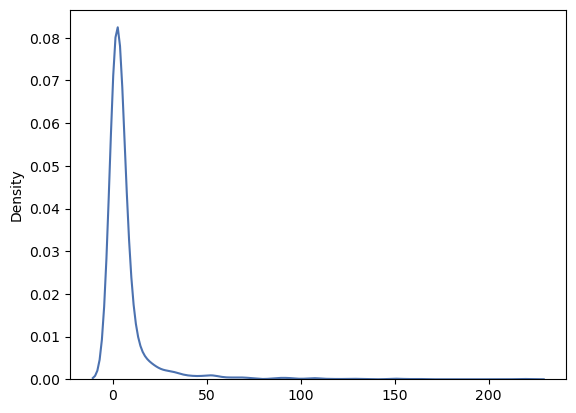

In [78]:
sns.kdeplot(all_metrics.iloc[10]["dist.dists"].flatten())

In [60]:
all_metrics = all_metrics.drop(2)

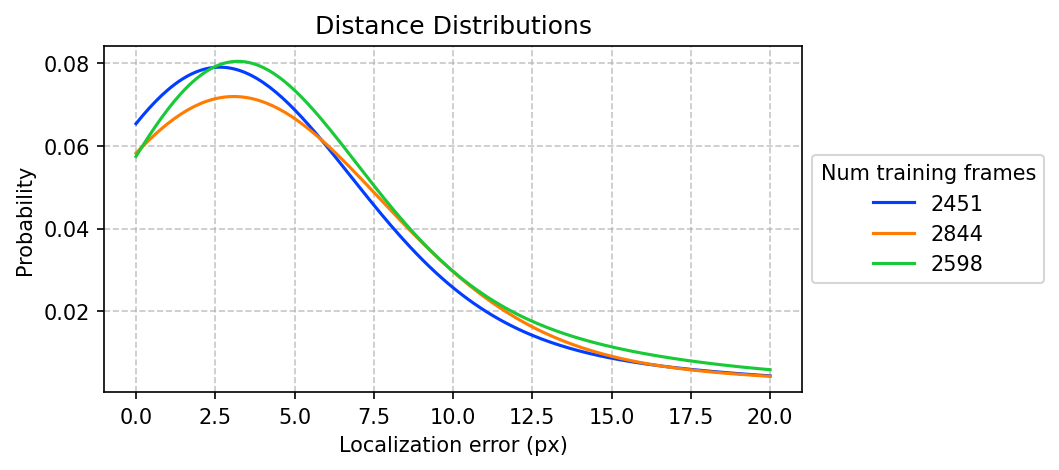

In [62]:

colormap = sns.color_palette("bright", len(all_metrics))

plt.figure(figsize=(6, 3), dpi=150, facecolor="w")


for i in range(0,3):
    # sns.histplot(all_metrics.iloc[i]["dist.dists"].flatten(), binrange=(0, 20), kde=True, kde_kws={"clip": (0, 20)}, stat="probability", color = colormap[i])
    model_name = all_metrics.iloc[i]['model_name'].split(".n=")[-1]

    sns.kdeplot(all_metrics.iloc[i]["dist.dists"].flatten(), color = colormap[i],clip=(0,20), label=model_name)
# Customize the plot
plt.xlabel("Localization error (px)")
plt.ylabel("Probability")
plt.title("Distance Distributions", fontsize=12)
plt.legend(title="Num training frames", loc='center left', bbox_to_anchor=(1,0.5))
plt.grid(True, linestyle="--", alpha=0.7)
# Show the plot
plt.show()

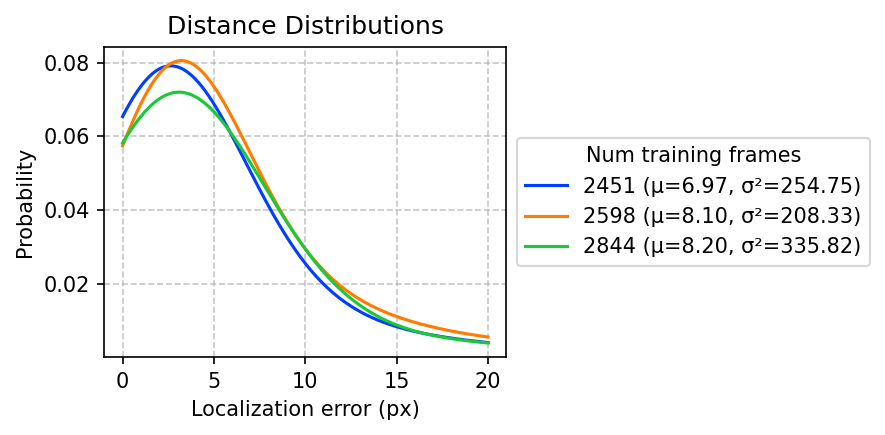

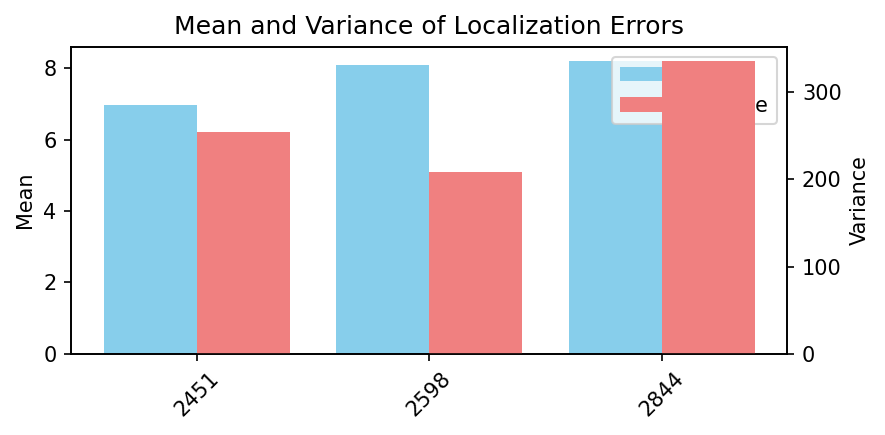

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import numpy as np

# Prepare storage
model_entries = []

# Collect and process data
for i in range(0,3):
    raw_data = all_metrics.iloc[i]["dist.dists"].flatten()
    dist_data = raw_data[np.isfinite(raw_data)]  # Remove NaN, inf, -inf

    if len(dist_data) == 0:
        print(f"Warning: No valid data for index {i}")
        continue

    model_name = all_metrics.iloc[i]['model_name']
    num_train_frames = int(model_name.split(".n=")[-1])

    # Fit normal distribution
    mu, std = norm.fit(dist_data)
    var = std**2

    model_entries.append({
        "frames": num_train_frames,
        "mu": mu,
        "var": var,
        "data": dist_data,
        "label": str(num_train_frames)
    })

# Sort entries by number of training frames
model_entries.sort(key=lambda x: x["frames"])

# Set up plot
colormap = sns.color_palette("bright", len(model_entries))
plt.figure(figsize=(6, 3), dpi=150, facecolor="w")

# Plot KDEs
for i, entry in enumerate(model_entries):
    sns.kdeplot(entry["data"], color=colormap[i], clip=(0, 20),
                label=f"{entry['label']} (μ={entry['mu']:.2f}, σ²={entry['var']:.2f})")

plt.xlabel("Localization error (px)")
plt.ylabel("Probability")
plt.title("Distance Distributions", fontsize=12)
plt.legend(title="Num training frames", loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Bar plot for mean and variance
means = [entry["mu"] for entry in model_entries]
variances = [entry["var"] for entry in model_entries]
labels = [entry["label"] for entry in model_entries]

fig, ax1 = plt.subplots(figsize=(6, 3), dpi=150, facecolor="w")

x = np.arange(len(labels))

ax1.bar(x - 0.2, means, width=0.4, label='Mean', color='skyblue')
ax1.set_ylabel("Mean")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45)

# Second axis for variance
ax2 = ax1.twinx()
ax2.bar(x + 0.2, variances, width=0.4, label='Variance', color='lightcoral')
ax2.set_ylabel("Variance")

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')

plt.title("Mean and Variance of Localization Errors")
plt.tight_layout()
plt.show()


### Plot Object Keypoint Similarity (OKS)
- takes into account factors such as landmark visibility, animal size and difficulty locating keypoints 
- ideally range [0, 1]

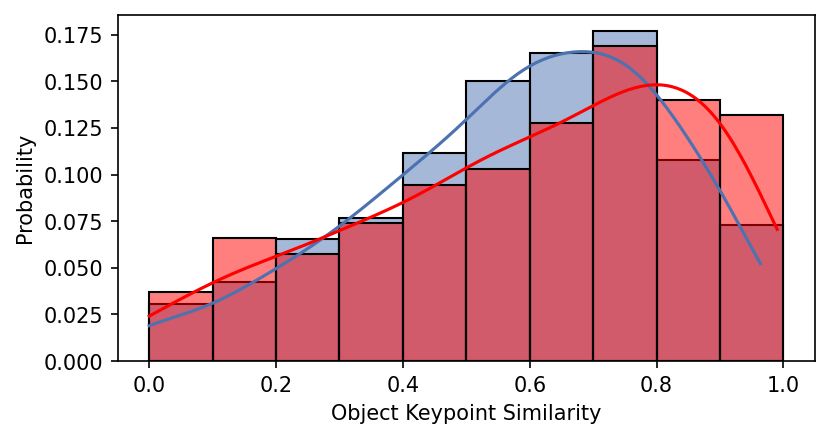

In [52]:
plt.figure(figsize=(6, 3), dpi=150, facecolor="w")
sns.histplot(metrics["oks_voc.match_scores"].flatten(), binrange=(0, 1), kde=True, kde_kws={"clip": (0, 1)}, stat="probability")
sns.histplot(latest_metrics["oks_voc.match_scores"].flatten(), binrange=(0, 1), kde=True, kde_kws={"clip": (0, 1)}, stat="probability", color="red")

plt.xlabel("Object Keypoint Similarity");

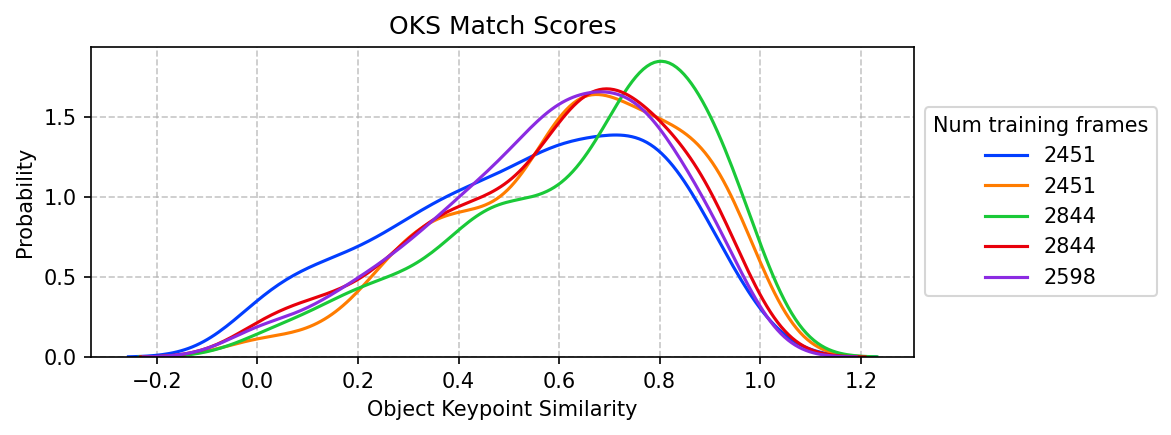

In [53]:
colormap = sns.color_palette("bright", len(all_metrics))

plt.figure(figsize=(8, 3), dpi=150, facecolor="w")


for i in range(0,5):
    # sns.histplot(all_metrics.iloc[i]["dist.dists"].flatten(), binrange=(0, 20), kde=True, kde_kws={"clip": (0, 20)}, stat="probability", color = colormap[i])
    model_name = all_metrics.iloc[i]['model_name'].split(".n=")[-1]
    sns.kdeplot(all_metrics.iloc[i]["oks_voc.match_scores"].flatten(), color = colormap[i],clip=(-5,20), label=model_name)
# Customize the plot
plt.xlabel("Object Keypoint Similarity")
plt.ylabel("Probability")
plt.title("OKS Match Scores", fontsize=12)
plt.legend(title="Num training frames", loc='center left', bbox_to_anchor=(1,0.5))
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
# Show the plot
plt.show()


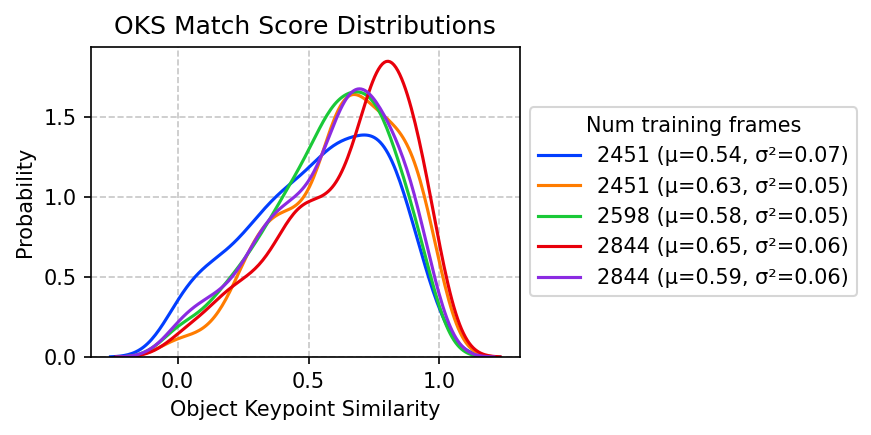

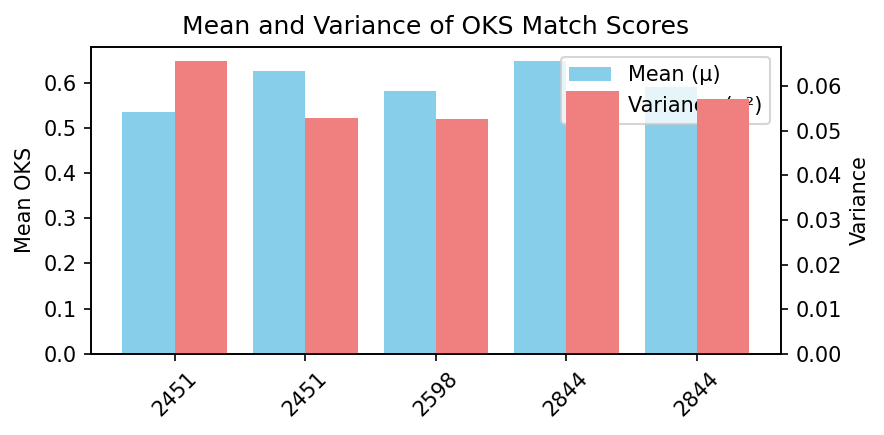

In [54]:

from scipy.stats import norm
import numpy as np

# Sort by number of training frames
all_metrics_sorted = all_metrics.copy()
all_metrics_sorted["num_train_frames"] = all_metrics_sorted["model_name"].apply(lambda x: int(x.split(".n=")[-1]))
all_metrics_sorted = all_metrics_sorted.sort_values("num_train_frames").reset_index(drop=True)

colormap = sns.color_palette("bright", len(all_metrics_sorted))

plt.figure(figsize=(6, 3), dpi=150, facecolor="w")

means = []
variances = []
labels = []

for i in range(len(all_metrics_sorted)):
    raw_data = all_metrics_sorted.iloc[i]["oks_voc.match_scores"].flatten()
    dist_data = raw_data[np.isfinite(raw_data)]  # Remove NaN, inf, -inf

    if len(dist_data) == 0:
        print(f"Warning: No valid data for index {i}")
        continue

    model_name = all_metrics_sorted.iloc[i]['model_name'].split(".n=")[-1]

    # Fit to normal distribution
    mu, std = norm.fit(dist_data)
    var = std**2

    means.append(mu)
    variances.append(var)
    labels.append(model_name)

    # Plot KDE
    sns.kdeplot(dist_data, color=colormap[i], clip=(-5, 20), label=f"{model_name} (μ={mu:.2f}, σ²={var:.2f})")

# Customize the KDE plot
plt.xlabel("Object Keypoint Similarity")
plt.ylabel("Probability")
plt.title("OKS Match Score Distributions", fontsize=12)
plt.legend(title="Num training frames", loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting mean and variance
fig, ax1 = plt.subplots(figsize=(6, 3), dpi=150, facecolor="w")

x = np.arange(len(labels))

ax1.bar(x - 0.2, means, width=0.4, label='Mean (μ)', color='skyblue')
ax1.set_ylabel("Mean OKS")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45)

# Create second y-axis for variance
ax2 = ax1.twinx()
ax2.bar(x + 0.2, variances, width=0.4, label='Variance (σ²)', color='lightcoral')
ax2.set_ylabel("Variance")

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')

plt.title("Mean and Variance of OKS Match Scores")
plt.tight_layout()
plt.show()


### Precision-recall curves: how well does the model do at different thresholds of OKS scores
- higher the threshold, more stringent the criteria for classifying prediction as correct 

mAP: 0.17443691413373885 0.30960208055356697
mAR: 0.3226923076923077 0.37736625514403294


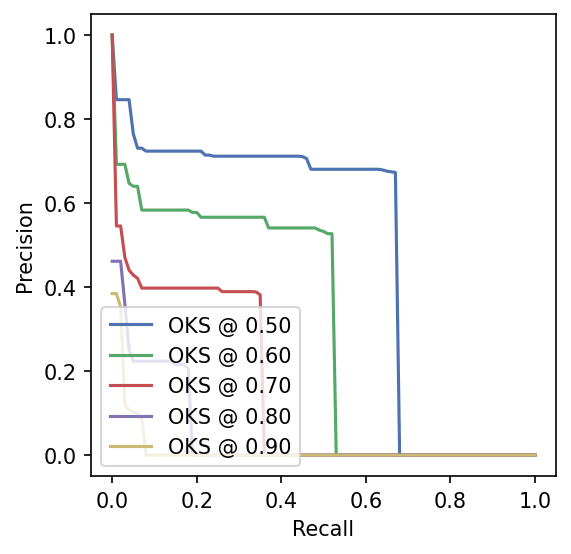

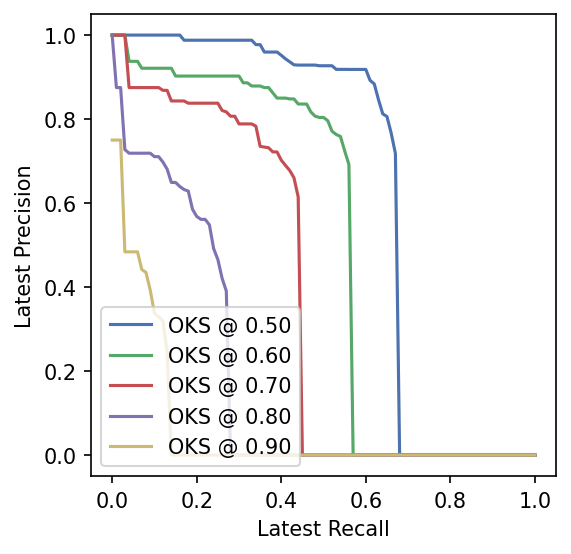

In [55]:
plt.figure(figsize=(4, 4), dpi=150, facecolor="w")
for precision, thresh in zip(metrics["oks_voc.precisions"][::2], metrics["oks_voc.match_score_thresholds"][::2]):
    plt.plot(metrics["oks_voc.recall_thresholds"], precision, "-", label=f"OKS @ {thresh:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left");

plt.figure(figsize=(4, 4), dpi=150, facecolor="w")
for precision, thresh in zip(latest_metrics["oks_voc.precisions"][::2], latest_metrics["oks_voc.match_score_thresholds"][::2]):
    plt.plot(latest_metrics["oks_voc.recall_thresholds"], precision, "-", label=f"OKS @ {thresh:.2f}")
plt.xlabel("Latest Recall")
plt.ylabel("Latest Precision")
plt.legend(loc="lower left");

# summary stats (mean Average Precision and mean Average Recall)
print("mAP:", metrics["oks_voc.mAP"], latest_metrics["oks_voc.mAP"])
print("mAR:", metrics["oks_voc.mAR"], latest_metrics["oks_voc.mAR"])


### mAP and mAR comparisons across models

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


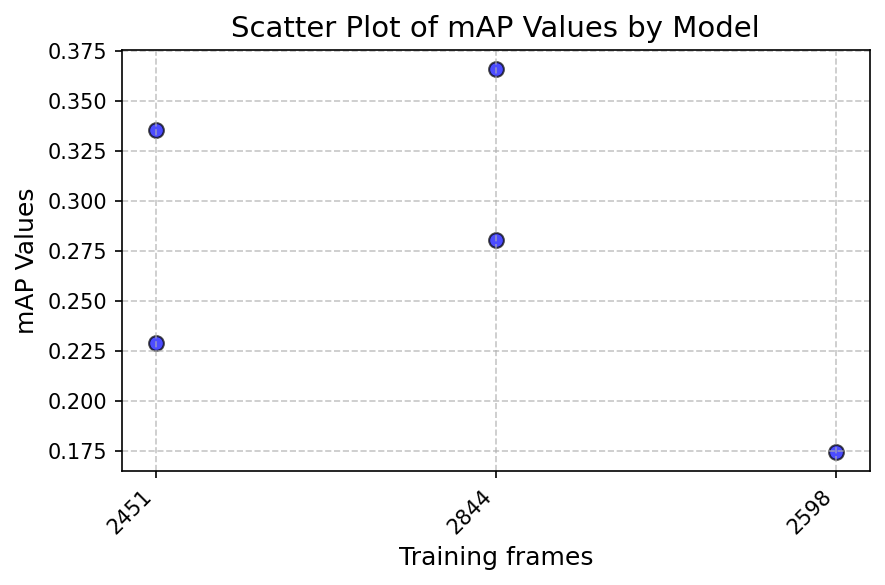

In [56]:
# Example data for all_metrics

# Extract model names (last part of the path after the last '\')
all_metrics["training_frames"] = all_metrics["model_name"].apply(lambda x: x.split(".n=")[-1])
# Create the scatter plot
plt.figure(figsize=(6, 4), dpi=150, facecolor="w")
plt.scatter(all_metrics["training_frames"], all_metrics["oks_voc.mAP"], color="blue", s=50, edgecolor="black", alpha=0.7)
# plt.scatter(all_metrics["training_frames"], all_metrics["oks_voc.mAR"], color="red", s=100, edgecolor="black", alpha=0.7)

# Customize the plot
plt.xlabel("Training frames", fontsize=12)
plt.ylabel("mAP Values", fontsize=12)
plt.title("Scatter Plot of mAP Values by Model", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.7)
# Show values on the x-axis with a tilt for readability
plt.xticks(rotation=45, ha="right")
# Show the plot
plt.tight_layout()
plt.show()

### body parts confidence comparison

### plot across animals + across days